In [2]:
# Unzip the dataset
import zipfile
import os

# Find the zip file
zip_files = [f for f in os.listdir() if f.endswith('.zip')]
print("Found zip:", zip_files)

with zipfile.ZipFile(zip_files[0], "r") as z:
    z.extractall()

# Check what got extracted
print(os.listdir("northstar_dataset"))

Found zip: ['northstar_dataset (1).zip']
['data_dictionary.csv', 'deliveries.csv', 'app_events.csv', 'complaints.csv', 'incidents.csv', 'northstar_dataset', 'hubs.csv', 'drivers.csv', 'README.txt', 'customers.csv', 'vehicles.csv', 'orders.csv']


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
orders     = pd.read_csv("northstar_dataset/orders.csv")
deliveries = pd.read_csv("northstar_dataset/deliveries.csv")
complaints = pd.read_csv("northstar_dataset/complaints.csv")
drivers    = pd.read_csv("northstar_dataset/drivers.csv")
vehicles   = pd.read_csv("northstar_dataset/vehicles.csv")
incidents  = pd.read_csv("northstar_dataset/incidents.csv")

print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Complaints:", complaints.shape)
print(deliveries.head())

Orders: (1250, 11)
Deliveries: (950, 13)
Complaints: (320, 10)
  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0             

Missing values:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64


/tmp/ipykernel_3691/2855605571.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries['customer_rating_post_delivery'].fillna(


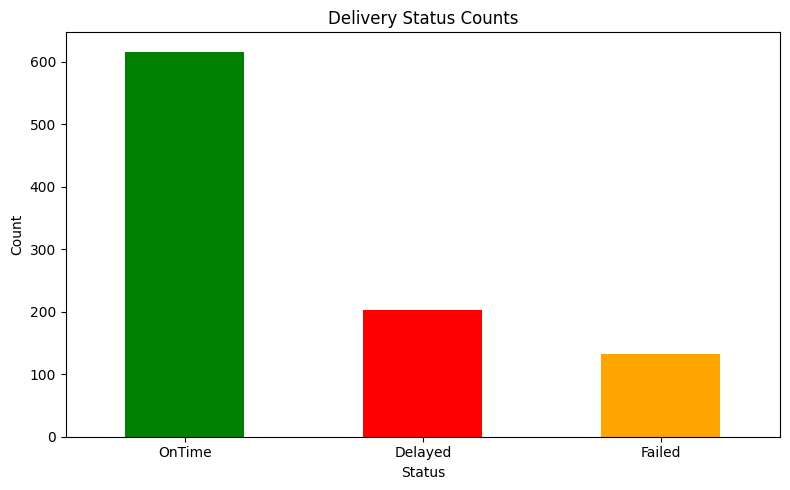

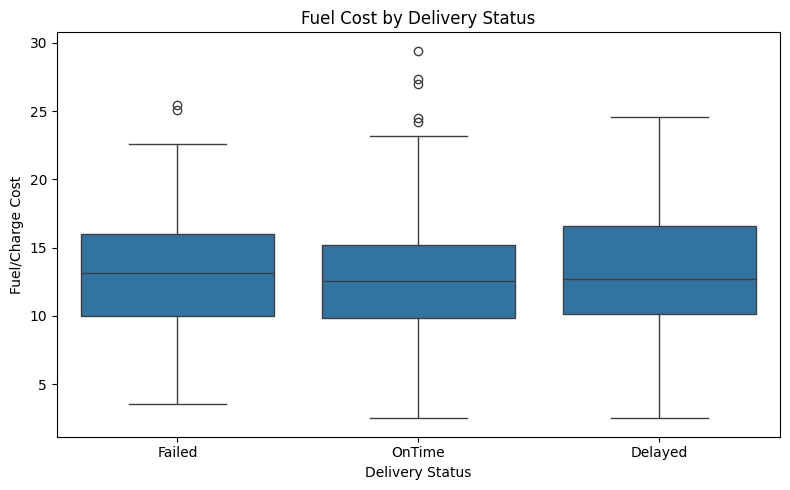

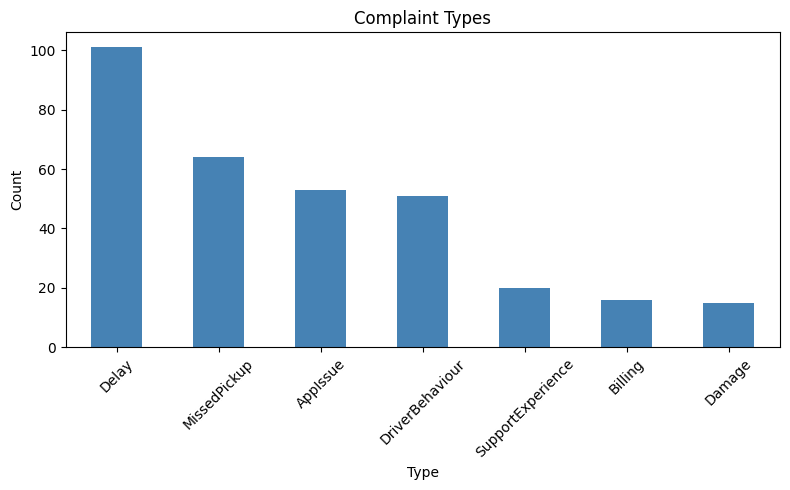


Delivery distance stats:
Mean: 13.909315789473684
Std: 7.473970019182938
Max: 41.94


In [4]:
# --- Data Cleaning ---
# Check missing values
print("Missing values:")
print(deliveries.isnull().sum())

# Fill missing ratings with median
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)

# --- Chart 1: Delivery status counts ---
plt.figure(figsize=(8,5))
deliveries['delivery_status'].value_counts().plot(kind='bar', color=['green','red','orange'])
plt.title('Delivery Status Counts')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Chart 2: Fuel cost by delivery status ---
plt.figure(figsize=(8,5))
sns.boxplot(data=deliveries, x='delivery_status', y='fuel_or_charge_cost')
plt.title('Fuel Cost by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Fuel/Charge Cost')
plt.tight_layout()
plt.show()

# --- Chart 3: Complaint types ---
plt.figure(figsize=(8,5))
complaints['complaint_type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Complaint Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- NumPy stats ---
print("\nDelivery distance stats:")
print("Mean:", np.mean(deliveries['route_distance_km']))
print("Std:", np.std(deliveries['route_distance_km']))
print("Max:", np.max(deliveries['route_distance_km']))

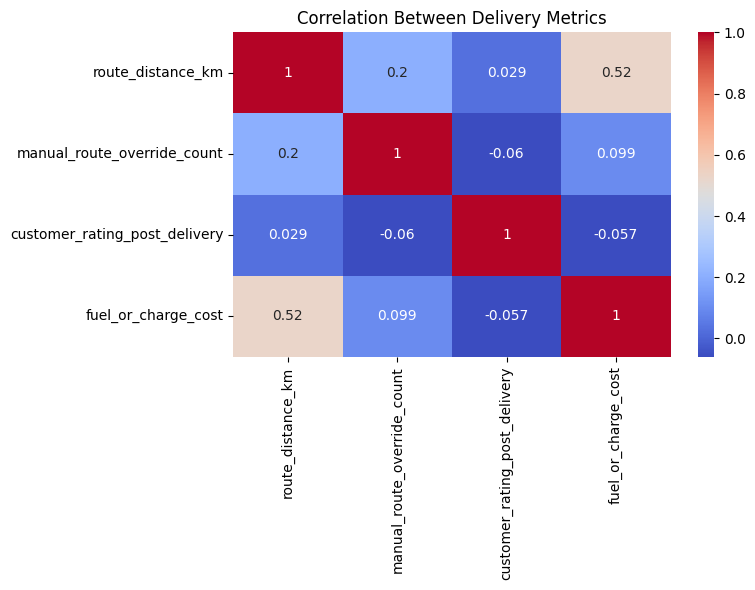

In [5]:
# Chart 4 - Correlation heatmap of delivery metrics
plt.figure(figsize=(8,6))
numeric_cols = deliveries[['route_distance_km',
                            'manual_route_override_count',
                            'customer_rating_post_delivery',
                            'fuel_or_charge_cost']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Delivery Metrics')
plt.tight_layout()
plt.show()